<a href="https://colab.research.google.com/github/LiviaMelgaco/teste04_IC_st/blob/main/simulacao_glarmaPOISSON.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulação de série por método de Monte Carlo
## Estimando betas do GLARMA(1,0) e comparando-os para phi = 0.3 e phi = 0.8.

In [ ]:
####### Simulação de Monte Carlo - GLARMA(1,0) Poisson #######
####### Comparando phi = 0.3 e phi = 0.8                #######

RNGkind(kind = "Mersenne-Twister",
        normal.kind = "Inversion",
        sample.kind = "Rejection")


install.packages("pacman")
library("pacman")
pacman::p_load(glarma)

set.seed(222)



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
##### PARAMETROS #####

n     <- 200          # tamanho de cada série simulada

beta0 <- 1
beta1 <- 0.5
beta2 <- -0.1
phis  <- c(0.3, 0.8)   # cenários de phi a comparar

Rs <- setNames(c(1000, 5883), as.character(phis))          #número de réplicas de Monte Carlo
#usando 5884 repeticoes para o phi=0.8 pq qnd coloco 1000 apenas 170 convergiram, entao pra ter uma amostra de 1000 preciso de aproximadamente 5884 repetições

In [ ]:

##### FUNÇAO GERADORA GLARMA ######

## Função: gera UMA série GLARMA(1,0) e ajusta o modelo,
# devolvendo os coeficientes estimados (ou NA se não convergir)

simula_e_ajusta <- function(n, beta0, beta1, beta2, phi) {

  x1 <- rnorm(n, mean = 0, sd = 1)
  x2 <- rnorm(n, mean = 0, sd = 1)

  z   <- numeric(n)
  eta <- numeric(n)
  mu  <- numeric(n)
  y   <- numeric(n)
  e   <- numeric(n)

  z_ant <- 0
  e_ant <- 0

  for (t in 1:n) {
    z[t]   <- phi * (z_ant + e_ant)
    eta[t] <- beta0 + beta1 * x1[t] + beta2 * x2[t] + z[t]
    mu[t]  <- exp(eta[t])
    y[t]   <- rpois(1, lambda = mu[t])
    e[t]   <- (y[t] - mu[t]) / sqrt(mu[t])

    z_ant <- z[t]
    e_ant <- e[t]
  }

  X_matriz <- cbind(intercept = 1, x1 = x1, x2 = x2)

  ajuste <- tryCatch(  #tryCatch se der erro, retorna NULL
    suppressWarnings(
      glarma(y, X_matriz,
             type      = "Poi",
             method    = "FS",
             residuals = "Pearson",
             phiLags   = 1)
    ),
    error = function(cnd) NULL
  )

  # se o glarma não convergir/der erro para essa réplica, devolve NA
  if (is.null(ajuste)) {
    return(c(NA_real_, NA_real_, NA_real_, NA_real_))
  }

  coefs <- unlist(coef(ajuste)) #unlist() achata a lista preservando a ordem.

  if (length(coefs) != 4) {  #só garantindo que se der algo errado, vai virar NA tb
    return(c(NA_real_, NA_real_, NA_real_, NA_real_))
  }

  coefs <- as.numeric(coefs)
  coefs[c(2, 3, 4, 1)]  # reordena: beta0, beta1, beta2, phi
}


In [ ]:
##### MONTE CARLO #####

resultados <- list()


for (phi_val in phis) {

  R_val <- Rs[[as.character(phi_val)]]  # número de réplicas DESSE phi

  cat("Rodando Monte Carlo para phi =", phi_val, "com R =", R_val, "réplicas\n")

  estimativas <- matrix(NA_real_, nrow = R_val, ncol = 4)
  colnames(estimativas) <- c("beta0", "beta1", "beta2", "phi")

  for (r in 1:R_val) {
    estimativas[r, ] <- simula_e_ajusta(n, beta0, beta1, beta2, phi_val)
    if (r %% 500 == 0) cat("  réplica", r, "de", R_val, "\n") #tipo uma barra de progressão, a cada 50 réplicas
  }

  resultados[[as.character(phi_val)]] <- estimativas
}



Rodando Monte Carlo para phi = 0.3 com R = 1000 réplicas
  réplica 500 de 1000 
  réplica 1000 de 1000 
Rodando Monte Carlo para phi = 0.8 com R = 5883 réplicas
  réplica 500 de 5883 
  réplica 1000 de 5883 
  réplica 1500 de 5883 
  réplica 2000 de 5883 
  réplica 2500 de 5883 
  réplica 3000 de 5883 
  réplica 3500 de 5883 
  réplica 4000 de 5883 
  réplica 4500 de 5883 
  réplica 5000 de 5883 
  réplica 5500 de 5883 


In [ ]:
##### EQM E MEDIAS #####

tabela_larga <- data.frame(parametro = c("beta0", "beta1", "beta2", "phi"))

for (phi_val in phis) {

  R_val <- Rs[[as.character(phi_val)]]
  est   <- resultados[[as.character(phi_val)]]
  vt    <- c(beta0, beta1, beta2, phi_val)  # valor verdadeiro de cada parâmetro nesse cenário

  #filtrando as NA's do calculo e da tabela
  est_validas <- est[stats::complete.cases(est), , drop = FALSE]
  n_validas   <- nrow(est_validas)

  medias <- colMeans(est_validas)
  eqm    <- colMeans(sweep(est_validas, 2, vt, FUN = "-")^2)

  tabela_larga[[paste0("media_phi", phi_val)]] <- round(medias, 4)
  tabela_larga[[paste0("eqm_phi",   phi_val)]] <- round(eqm, 4)

  cat("phi =", phi_val, "->", n_validas, "de", R_val, "réplicas convergiram\n")
}


phi = 0.3 -> 1000 de 1000 réplicas convergiram
phi = 0.8 -> 1035 de 5883 réplicas convergiram


In [ ]:
##### TABELA E GRAFICO FINAL #####

## tabela
cat("\nValores verdadeiros dos betas: beta0 =", beta0,
    ", beta1 =", beta1, ", beta2 =", beta2, "\n\n")

print(tabela_larga)



Valores verdadeiros dos betas: beta0 = 1 , beta1 = 0.5 , beta2 = -0.1 

  parametro media_phi0.3 eqm_phi0.3 media_phi0.8 eqm_phi0.8
1     beta0       0.9910     0.0059       1.3278     0.3077
2     beta1       0.5002     0.0012       0.5738     0.0260
3     beta2      -0.0998     0.0011      -0.1120     0.0170
4       phi       0.3012     0.0012       0.2664     0.3007


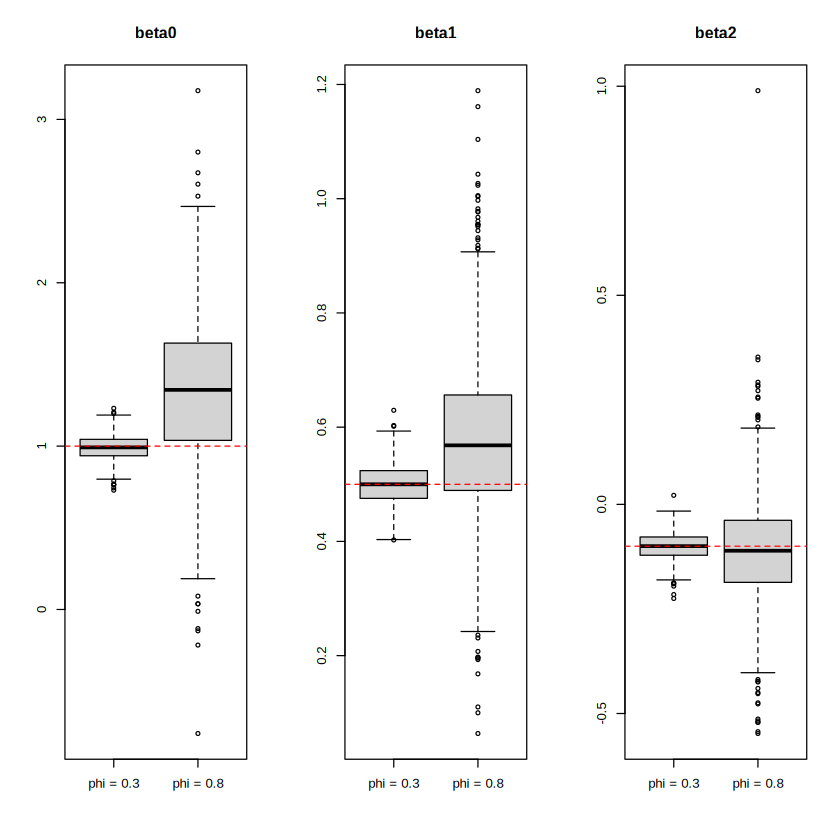

In [ ]:
##boxplot

par(mfrow = c(1, 3))
for (i in 1:3) {
  boxplot(
    resultados[["0.3"]][, i], resultados[["0.8"]][, i],
    names = c("phi = 0.3", "phi = 0.8"),
    main = colnames(estimativas)[i]
  )
  abline(h = c(beta0, beta1, beta2)[i], col = "red", lty = 2)
}


In [ ]:
writeLines(capture.output(sessionInfo()), "sessionInfo.txt")